# 1. Project Setup


In [37]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
# Statmodel libraries
import statsmodels.api as sm

# sklearn libraries
from sklearn import set_config
from sklearn import tree
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, ConfusionMatrixDisplay, confusion_matrix
set_config(transform_output='pandas') # set pandas output for all sklearn transformers

In [2]:
# set global hyperparameters
random_state = 123
n_jobs = -1
max_iter = 1000

In [3]:
# train dataset
loan_train = pd.read_csv('/mnt/d/torch-playground/data/processed/loan_train.csv')
X_train = loan_train.drop(columns = 'remainder__loan_status')
y_train = loan_train['remainder__loan_status']

# validation dataset
loan_val = pd.read_csv('/mnt/d/torch-playground/data/processed/loan_val.csv')
X_val = loan_val.drop(columns = 'remainder__loan_status')
y_val = loan_val['remainder__loan_status']

# test dataset
loan_test = pd.read_csv('/mnt/d/torch-playground/data/processed/loan_test.csv')
X_test = loan_test.drop(columns = 'remainder__loan_status')
y_test = loan_test['remainder__loan_status']

# 2. Modeling
Develop various model type and validate on the validation set.
generate predictions on the test set.
For data processing,  check [3.0.-ant-eda.ipynb](/mnt/d/torch-playground/notebooks/3.0-eda.ipynb) for the data processing steps.

## 2.1 Use LogisticRegression classifier

In [4]:
logit_clf = LogisticRegression(random_state=random_state, n_jobs=n_jobs, max_iter=max_iter) # use all cores
logit_clf.fit(X_train, y_train)

LogisticRegression(max_iter=1000, n_jobs=-1, random_state=123)

## 2.2 Use Stochastic Gradient Descent Classifier (SGDClassifier)
Stochastic (Random) Gradeint Descent is an optimization technique. It does not belong corespond to a specific family of machine learning models. It is a way of training a model, [details can be found here](https://scikit-learn.org/stable/modules/sgd.html).

Let's model loan status using SGDClassifier:


In [5]:
# define model
sgd_clf = SGDClassifier(loss='log_loss', random_state=random_state, n_jobs=n_jobs, max_iter=max_iter, alpha=1.0) # use all cores
sgd_clf.fit(X_train, y_train)

SGDClassifier(alpha=1.0, loss='log_loss', n_jobs=-1, random_state=123)

## 2.3 Use Decision Tree Classifier


In [39]:
tree_clf = tree.DecisionTreeClassifier(random_state=random_state) # use all cores
tree_clf.fit(X_train, y_train)


DecisionTreeClassifier(random_state=123)

## 2.2 Use StatModels

In [6]:
X_train_array = X_train.to_numpy()
y_train_array = y_train.to_numpy()

# Add a constant to the model
X_train_array = sm.add_constant(X_train_array)

# step 1: model class to describe the model
stat_model = sm.Logit(y_train_array, X_train_array)

# step 2: fit the model use class method
stat_model_results = stat_model.fit(method='lbfgs', maxiter=1000, full_output=True) # set same hyperparameters as sklearn

In [7]:
# step 3: inspect model results, use print for better formatting
print(stat_model_results.summary())

                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                31471
Model:                          Logit   Df Residuals:                    31451
Method:                           MLE   Df Model:                           19
Date:                Tue, 01 Apr 2025   Pseudo R-squ.:                  0.5857
Time:                        16:01:07   Log-Likelihood:                -6905.9
converged:                       True   LL-Null:                       -16667.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.7014      0.154    -11.041      0.000      -2.003      -1.399
x1            -0.0009      0.018     -0.051      0.960      -0.037       0.035
x2             0.0488      0.042      1.149      0.2

# 3. Model Evaluation


In [9]:
def metric(y_true, y_pred):
    """
    Function to calculate the metrics for the model"""
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    return {
        'accuracy_score': accuracy,
        'precision_score': precision,
        'recall_score': recall,
        'f1_score': f1
    }

In [ ]:
# logit metrics
logit_preds = logit_clf.predict(X_val)
logit_metrics = metric(y_val, logit_preds)

# sgd metrics
sgd_preds = sgd_clf.predict(X_val)
sgd_metrics = metric(y_val, sgd_preds)

# tree metrics
tree_preds = tree_clf.predict(X_val)
tree_metrics = metric(y_val, tree_preds)

# stat_model metrics
X_val_with_const = sm.add_constant(X_val.to_numpy())
stat_model_preds = stat_model_results.predict(X_val_with_const) # get the predicted probabilities
stat_model_preds = np.where(stat_model_preds > 0.5, 1, 0) # convert to binary

# confusion matrix
cm = confusion_matrix(y_val, stat_model_preds)

/home/vietanhdong/anaconda3/envs/env-torch/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [41]:
print(confusion_matrix(y_val, tree_preds, labels=[0, 1]))

[[4905  344]
 [ 330 1167]]


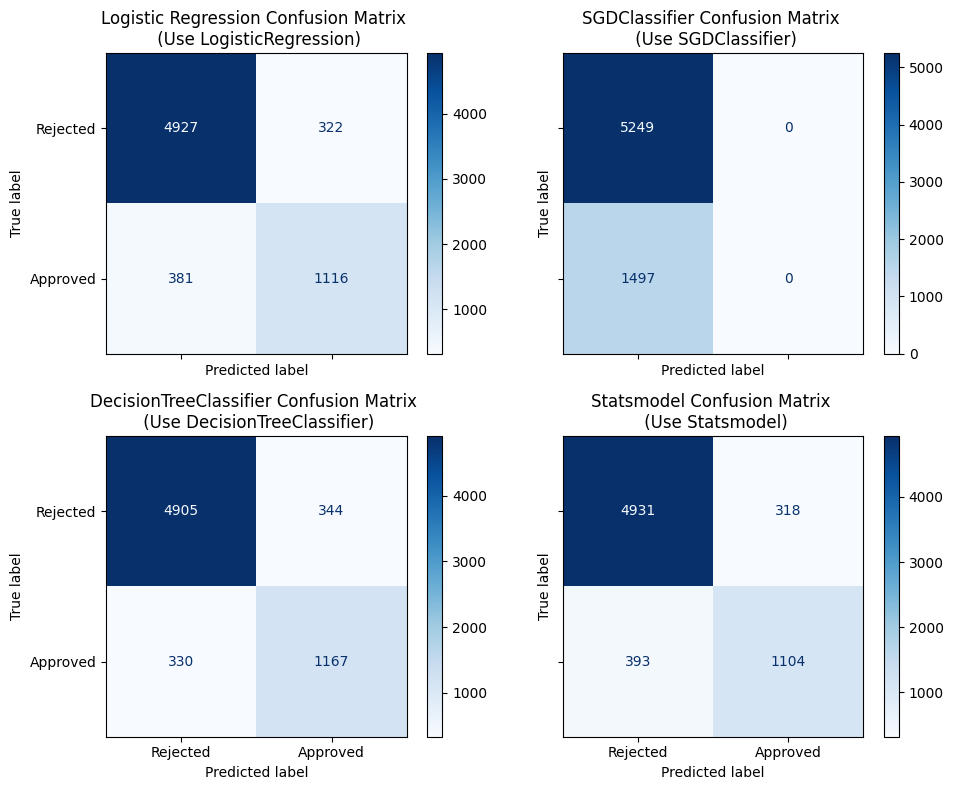

In [43]:
fig, ax = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
ax = ax.flatten()
# plot LogisticRegression confusion matrix
ConfusionMatrixDisplay.from_estimator(logit_clf, X_val, y_val, display_labels=['Rejected', 'Approved'], cmap='Blues',
                                      ax=ax[0])
ax[0].set_title('Logistic Regression Confusion Matrix \n (Use LogisticRegression)', fontsize=12)

# plot SGDClassifier confusion matrix
ConfusionMatrixDisplay.from_estimator(sgd_clf, X_val, y_val, display_labels=['Rejected', 'Approved'], cmap='Blues',
                                      ax=ax[1])
ax[1].set_title('SGDClassifier Confusion Matrix \n (Use SGDClassifier)', fontsize=12)

# plot DecisionTreeClassifier confusion matrix
ConfusionMatrixDisplay.from_estimator(tree_clf, X_val, y_val, display_labels=['Rejected', 'Approved'], cmap='Blues',
                                      ax=ax[2])
ax[2].set_title('DecisionTreeClassifier Confusion Matrix \n (Use DecisionTreeClassifier)', fontsize=12)

# plot statsmodel confusion matrix
ConfusionMatrixDisplay.from_predictions(y_val, stat_model_preds, display_labels=['Rejected', 'Approved'], cmap='Blues',
                                        ax=ax[3])
ax[3].set_title('Statsmodel Confusion Matrix \n (Use Statsmodel)', fontsize=12)

plt.tight_layout()
plt.show()
